In [4]:
import pandas as pd
import numpy as np

In [15]:
dataset = pd.read_csv('data/train.csv')
dataset.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64
(593994, 13)


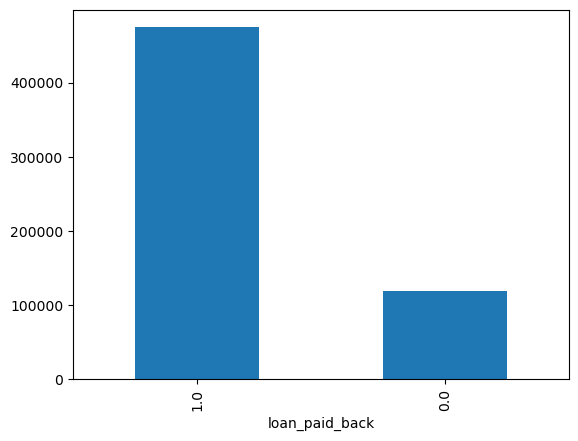

In [17]:
ones = dataset['loan_paid_back'].value_counts()
ones.plot(kind='bar')
print(ones)
print(dataset.shape)

In [19]:
dataset.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [21]:
dataset.drop_duplicates(inplace=True)
print(dataset.shape)

(593994, 13)


In [28]:
from sklearn.preprocessing import LabelEncoder
df_encoded = dataset.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

<Axes: >

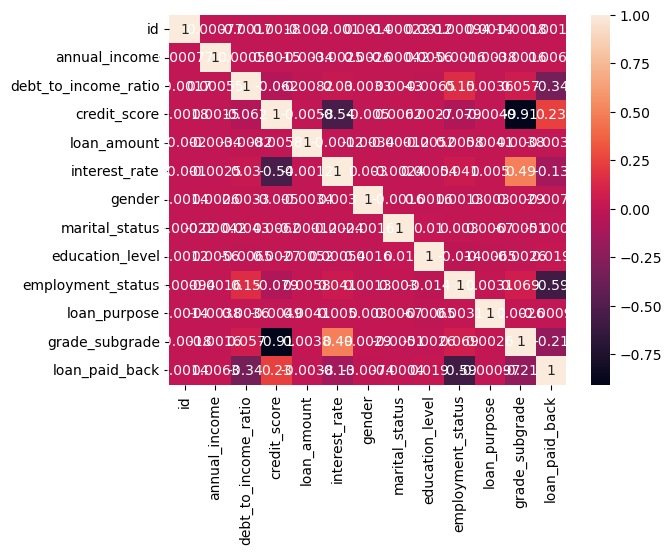

In [29]:
import seaborn as sns
corr = df_encoded.corr()
sns.heatmap(corr, annot=True)

In [30]:
df_encoded.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,1.0
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,0.0
2,2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,1.0
3,3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25,1.0
4,4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,1.0


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Split dataset
X = df_encoded.drop('loan_paid_back', axis=1)
y = df_encoded['loan_paid_back']

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [35]:
# Train model
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[17985  5915]
 [ 8735 86164]]
              precision    recall  f1-score   support

         0.0       0.67      0.75      0.71     23900
         1.0       0.94      0.91      0.92     94899

    accuracy                           0.88    118799
   macro avg       0.80      0.83      0.82    118799
weighted avg       0.88      0.88      0.88    118799



### **With Smote**

In [36]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [37]:
# Train model
rf.fit(X_train_sm, y_train_sm)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[17444  6456]
 [11011 83888]]
              precision    recall  f1-score   support

         0.0       0.61      0.73      0.67     23900
         1.0       0.93      0.88      0.91     94899

    accuracy                           0.85    118799
   macro avg       0.77      0.81      0.79    118799
weighted avg       0.87      0.85      0.86    118799

